<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/01_data_exploration/blob/main/02_radiographie_covid_classification_RF_Sareh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 0 - Import required libraries

import os  # library used to interact with files and folders
from pathlib import Path  # Handle file paths more easily
from collections import Counter # Import Counter to count how many times each element appears

import kagglehub     # Download datasets directly from Kaggle

import numpy as np   # Numerical computations
import pandas as pd  # Work with tables and dataframes

import cv2           # Image processing (OpenCV)

import matplotlib.pyplot as plt  # Plot images and graphs
import seaborn as sns            # Better visualizations

from sklearn.model_selection import train_test_split # Split dataset into train/test
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from skimage.feature import hog                      # Import the HOG feature extractor from scikit-image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Import evaluation metrics

In [2]:
# Cell 1- Download Kaggle dataset and define paths

path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
# download the COVID-19 radiography dataset from Kaggle

base_path = Path(path)
# convert the returned path( which is string) to a Path object

data_path = base_path / "COVID-19_Radiography_Dataset"
# create the path pointing to the main dataset folder

print("Dataset downloaded to:", base_path)
# show where the dataset has been downloaded

print("Main dataset folder:", data_path)
# show the path to the dataset containing images and masks

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset downloaded to: /kaggle/input/covid19-radiography-database
Main dataset folder: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [3]:
# Cell 2 - Inspect dataset structure

class_folders = [item for item in os.listdir(data_path) if os.path.isdir(data_path / item)]
# get all folder names inside the main dataset directory

print("Class folders found in the dataset:")
# print a message before listing class folders

print(class_folders)
# display all class folder names

Class folders found in the dataset:
['Normal', 'Lung_Opacity', 'Viral Pneumonia', 'COVID']


In [4]:
# Cell 3 - Check dataset summary table and image/mask filename matching

mismatch_report = []  # Create an empty list to store matching results for each class

for class_name in class_folders:  # Loop through each class folder

    class_path = data_path / class_name  # Build the full path of the current class
    images_path = class_path / "images"  # Path to the images folder
    masks_path = class_path / "masks"  # Path to the masks folder

    image_files = sorted(os.listdir(images_path))  # Get a sorted list of image filenames
    mask_files = sorted(os.listdir(masks_path))  # Get a sorted list of mask filenames

    filenames_match = image_files == mask_files  # Check whether image and mask filenames match exactly

    mismatch_report.append({
        "class_name": class_name,  # Store the class name
        "num_image_files": len(image_files),  # Store the number of image files
        "num_mask_files": len(mask_files),  # Store the number of mask files
        "filenames_match": filenames_match  # Store whether filenames match
    })

mismatch_df = pd.DataFrame(mismatch_report)  # Convert the matching report into a pandas DataFrame

mismatch_df  # Display the matching results

,class_name,num_image_files,num_mask_files,filenames_match
0,Normal,10192,10192,True
1,Lung_Opacity,6012,6012,True
2,Viral Pneumonia,1345,1345,True
3,COVID,3616,3616,True


In [5]:
# Cell 4 - Build the main dataframe with image and mask paths

data_rows = []  # List to store all samples

for class_name in class_folders:  # Loop through each class
    class_path = data_path / class_name

    images_path = class_path / "images"
    masks_path = class_path / "masks"

    image_files = sorted(os.listdir(images_path))  # Get all image filenames

    for filename in image_files:
        image_path = images_path / filename
        mask_path = masks_path / filename

        data_rows.append({
            "label": class_name,
            "image_path": str(image_path),
            "mask_path": str(mask_path)
        })

main_df = pd.DataFrame(data_rows)

print("Dataset size:", main_df.shape)
main_df.head()

Dataset size: (21165, 3)


,label,image_path,mask_path
0,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [8]:
# Cell 5 - Dataset inspection (RUN ONLY ONCE)
# This cell checks the size of all images and masks in the dataset.
# It is used only to verify whether images and masks have consistent dimensions.
# Since this operation scans the entire dataset and may take several minutes,
# it does NOT need to be executed every time the notebook runs, so it is disabled by default.

if False:  # Change to True if you want to run this dataset inspection

    image_sizes = []  # List to store the size (height, width) of every image
    mask_sizes = []   # List to store the size (height, width) of every mask

    for _, row in main_df.iterrows():  # Loop through every row of the dataframe

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)  # Load the X-ray image in grayscale
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)    # Load the corresponding lung mask

        if image is not None:  # Make sure the image was loaded successfully
            image_sizes.append(image.shape)  # Save the image size (height, width)

        if mask is not None:  # Make sure the mask was loaded successfully
            mask_sizes.append(mask.shape)  # Save the mask size (height, width)

    # Convert the list of sizes into a set to see only unique dimensions
    unique_image_sizes = set(image_sizes)  # Unique image sizes present in the dataset
    unique_mask_sizes = set(mask_sizes)    # Unique mask sizes present in the dataset

    print("Unique image sizes:", unique_image_sizes)  # Display all unique image dimensions
    print("Unique mask sizes:", unique_mask_sizes)    # Display all unique mask dimensions

    print("Image size counts:")  # Show how many images exist for each size
    print(Counter(image_sizes))  # Count occurrences of each image dimension

    print("\nMask size counts:")  # Show how many masks exist for each size
    print(Counter(mask_sizes))   # Count occurrences of each mask dimension

Unique image sizes: {(299, 299)}
Unique mask sizes: {(256, 256)}
Image size counts:
Counter({(299, 299): 21165})

Mask size counts:
Counter({(256, 256): 21165})


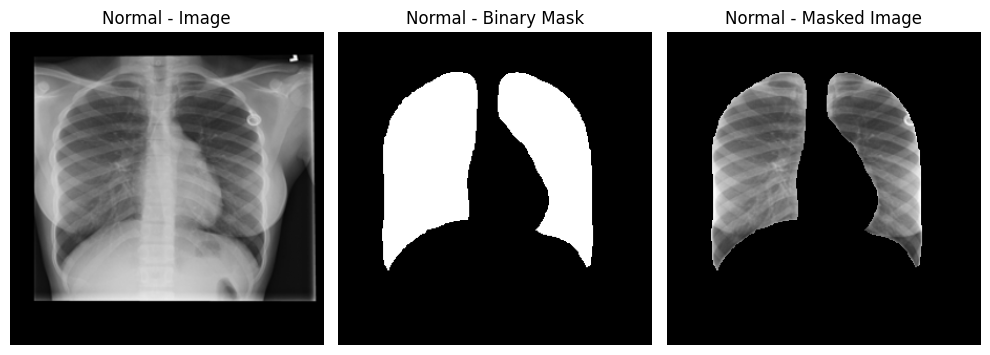

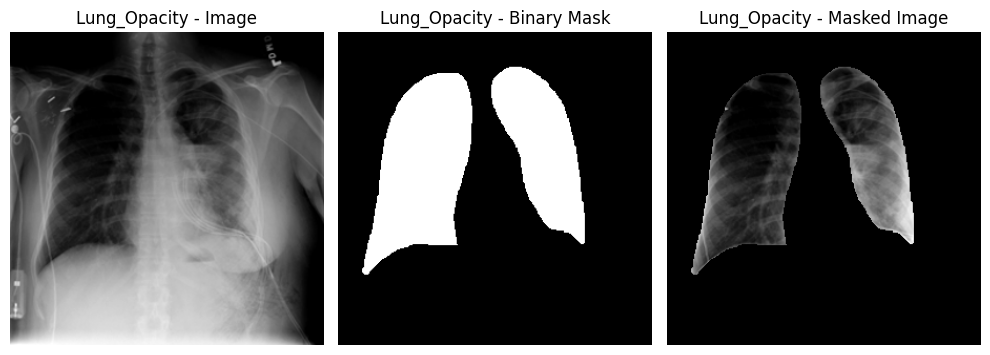

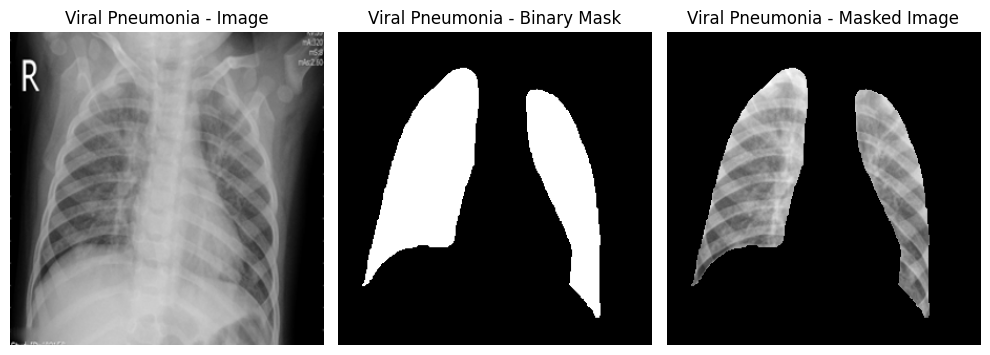

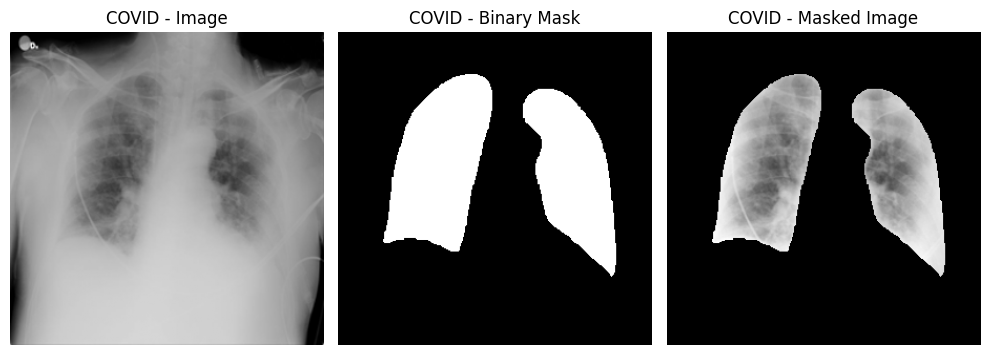

In [9]:
# Cell 6 - Visualize one sample from each class after resizing + thresholding the mask

for class_name in class_folders:  # Loop through each class

    sample = main_df[main_df["label"] == class_name].iloc[0]  # Select the first sample of the class

    image = cv2.imread(sample["image_path"], cv2.IMREAD_GRAYSCALE)  # Read the X-ray image in grayscale
    mask = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)  # Read the mask in grayscale

    # Resize mask to match image size
    mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]))

    # Convert resized mask back to binary
    _, mask_binary = cv2.threshold(mask_resized, 127, 255, cv2.THRESH_BINARY)

    # Apply binary mask to the image
    masked_image = cv2.bitwise_and(image, image, mask=mask_binary)

    plt.figure(figsize=(10,5))  # Create a new figure

    plt.subplot(1,3,1)  # First subplot
    plt.imshow(image, cmap="gray")  # Show original image
    plt.title(f"{class_name} - Image")
    plt.axis("off")

    plt.subplot(1,3,2)  # Second subplot
    plt.imshow(mask_binary, cmap="gray")  # Show binary mask
    plt.title(f"{class_name} - Binary Mask")
    plt.axis("off")

    plt.subplot(1,3,3)  # Third subplot
    plt.imshow(masked_image, cmap="gray")  # Show masked image
    plt.title(f"{class_name} - Masked Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()  # Display the figure

In [10]:
# Cell 7 - Preprocess all images for Random Forest

features_list = []  # Store one feature vector for each image
labels_list = []  # Store the class label for each image

target_size = (64, 64)  # Define the final fixed size for all processed images

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # Create CLAHE object for local contrast enhancement

for idx, row in main_df.iterrows():  # Loop through all rows of the dataframe

    image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)  # Read the X-ray image in grayscale
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)  # Read the lung mask in grayscale

    if image is None or mask is None:  # Skip the sample if image or mask could not be loaded
        continue

    mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]))  # Resize mask to match the image size

    _, mask_binary = cv2.threshold(mask_resized, 127, 255, cv2.THRESH_BINARY)  # Convert resized mask back to binary

    masked_image = cv2.bitwise_and(image, image, mask=mask_binary)  # Apply the binary mask to keep only the lung region

    resized_image = cv2.resize(masked_image, target_size)  # Resize the masked image to the target size

    enhanced_image = clahe.apply(resized_image)  # Apply CLAHE to improve local contrast

    flattened_image = enhanced_image.flatten()  # Flatten the 2D image into a 1D feature vector

    features_list.append(flattened_image)  # Add the feature vector to the features list
    labels_list.append(row["label"])  # Add the corresponding class label to the labels list

print("Number of processed images:", len(features_list))  # Print the number of processed images
print("Number of labels:", len(labels_list))  # Print the number of collected labels
print("Feature vector shape:", features_list[0].shape)  # Print the shape of one feature vector
print("Unique values in the last resized mask:", np.unique(mask_resized))  # Show unique pixel values of the last resized mask (sorted in ascending order).
print("Unique values in the last binary mask:", np.unique(mask_binary))  # Show unique pixel values of the last binary mask.(sorted in ascending order)

Number of processed images: 21165
Number of labels: 21165
Feature vector shape: (4096,)
Unique values in the last resized mask: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  65  66  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148
 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 176 177 179 180 181 182 183 184 185 186
 187 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 

In [11]:
# Cell 8 - Prepare data for machine learning

X = np.array(features_list)  # Convert the list of feature vectors into a NumPy matrix
y = np.array(labels_list)    # Convert the list of labels into a NumPy array

print("Feature matrix shape:", X.shape)  # Show the shape of X
print("Label vector shape:", y.shape)  # Show the shape of y

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # Use 20% of the data for testing
    random_state=42,     # Ensure reproducibility
    stratify=y           # Preserve class distribution in train and test sets
)

print("Training set shape:", X_train.shape)  # Show the shape of the training features
print("Testing set shape:", X_test.shape)  # Show the shape of the testing features
print("Training labels shape:", y_train.shape)  # Show the shape of the training labels
print("Testing labels shape:", y_test.shape)  # Show the shape of the testing labels

Feature matrix shape: (21165, 4096)
Label vector shape: (21165,)
Training set shape: (16932, 4096)
Testing set shape: (4233, 4096)
Training labels shape: (16932,)
Testing labels shape: (4233,)


In [11]:
# Cell 9 - Hyperparameter tuning for Random Forest using GridSearchCV

# Create the base Random Forest model
# No hyperparameters are fixed here because GridSearch will test them
rf = RandomForestClassifier(
    random_state=42,
    max_features="sqrt",      # fixed
    class_weight="balanced",   # fixed
    n_jobs=-1   # Use all CPU cores for faster training
)

# Define the hyperparameter search space
# GridSearch will try all possible combinations
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [1, 3, 5]
}

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,                 # The model to tune
    param_grid=param_grid,        # Hyperparameter combinations to test
    cv=5,                         # 5-fold cross-validation
    scoring="f1_macro",           # Evaluation metric for model selection
    n_jobs=-1,                    # Use all CPU cores
    return_train_score=True,      # Store training scores to check overfitting
    verbose=1                     # Show progress during training
)

# Run GridSearchCV on the training set
grid_search.fit(X_train, y_train)

# Extract the best trained model
best_rf_model = grid_search.best_estimator_

# Display the best hyperparameters
print("\nBest hyperparameters found:")
print(grid_search.best_params_)

# Display the best cross-validation score
print("\nBest mean cross-validation score (F1 macro):")
print(grid_search.best_score_)

# Display the best trained model
print("\nBest trained Random Forest model:")
print(best_rf_model)

# Retrieve the mean training score for the best model
best_index = grid_search.best_index_
train_score = grid_search.cv_results_["mean_train_score"][best_index]

print("\nMean training score of the best model:")
print(train_score)

# Convert all GridSearch results into a DataFrame for easier analysis
cv_results_df = pd.DataFrame(grid_search.cv_results_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best hyperparameters found:
{'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 200}

Best mean cross-validation score (F1 macro):
0.6695646636490677

Best trained Random Forest model:
RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, n_estimators=200, n_jobs=-1,
                       random_state=42)

Mean training score of the best model:
0.8631540500236088


###**Model selection analysis (GridSearchCV results)**

GridSearchCV evaluated 36 hyperparameter combinations using 5-fold cross-validation, resulting in a total of 180 model fits.

The best hyperparameters identified automatically by GridSearchCV were:

**n_estimators = 200
max_depth = 10  
min_samples_leaf = 3  
max_features = "sqrt"  
class_weight = "balanced"**

This configuration achieved the highest mean cross-validation F1-macro score:

**F1_macro (validation) = 0.6696**

However, the training score of this model is significantly higher:

**Training score = 0.8631**

The large difference between the training score and the validation score suggests that the model is overfitting the training data. In other words, the model learns the training samples very well but does not generalize as effectively to unseen data.

For this reason, the hyperparameters suggested by GridSearchCV were not directly adopted.

Instead, the results stored in `cv_results_` were carefully analyzed. By examining the relationship between `mean_train_score` and `mean_test_score`, a more balanced configuration was selected that provides a better trade-off between predictive performance and generalization ability.

The final hyperparameters were therefore chosen manually from the Grid Search results table.

In [12]:
# Cell 10 - Display the most relevant hyperparameters and scores from the GridSearchCV results.
# We analyze the mean training score and the mean validation score for each parameter combination.
# The goal is not only to find the highest validation score, but also to detect potential overfitting.
# Overfitting occurs when the training score is much higher than the validation score.
# Therefore, we manually inspect the CV results table to select a configuration that provides
# a good balance between performance and generalization.

print("\nGrid Search results (summary):")

print(cv_results_df[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "rank_test_score"
]])


Grid Search results (summary):
    param_n_estimators  param_max_depth  param_min_samples_leaf  \
0                  100                4                       1   
1                  200                4                       1   
2                  300                4                       1   
3                  100                4                       3   
4                  200                4                       3   
5                  300                4                       3   
6                  100                4                       5   
7                  200                4                       5   
8                  300                4                       5   
9                  100                6                       1   
10                 200                6                       1   
11                 300                6                       1   
12                 100                6                       3   
13                 200        

### **Final hyperparameter selection**

Although GridSearchCV identified a deeper Random Forest configuration as the best one according to the highest mean cross-validation F1-macro score, that model showed a relatively large gap between training and validation scores, indicating noticeable overfitting.

To obtain a better balance between predictive performance and generalization, the final model was selected manually from the Grid Search results table.

The selected hyperparameters are:

**n_estimators = 200  
max_depth = 8  
min_samples_leaf = 1  
max_features = "sqrt"  
class_weight = "balanced"**

This configuration was chosen because it provides a more balanced trade-off between training and validation performance, while reducing overfitting compared with the top-ranked deeper model.

In [12]:
# Cell 11 - Train the final selected Random Forest model

# Create the final Random Forest model using the manually selected hyperparameters
rf_model_final = RandomForestClassifier(
    n_estimators=200,          # Number of trees
    max_depth=8,               # Maximum depth of each tree
    min_samples_leaf=1,        # Minimum number of samples required in each leaf
    max_features="sqrt",       # Number of features considered at each split
    class_weight="balanced",   # Handle class imbalance
    random_state=42,           # Ensure reproducibility
    n_jobs=-1                  # Use all available CPU cores
)

# Train the final model on the full training set
rf_model_final.fit(X_train, y_train)

print("Final Random Forest model training completed.")

# Predict labels for the test set
y_pred = rf_model_final.predict(X_test)

print("Prediction on the test set completed.")

Final Random Forest model training completed.
Prediction on the test set completed.


Test Accuracy: 0.6477675407512402

Classification Report:
                 precision    recall  f1-score   support

          COVID       0.43      0.39      0.41       723
   Lung_Opacity       0.62      0.64      0.63      1203
         Normal       0.75      0.71      0.73      2038
Viral Pneumonia       0.58      0.90      0.71       269

       accuracy                           0.65      4233
      macro avg       0.60      0.66      0.62      4233
   weighted avg       0.65      0.65      0.65      4233



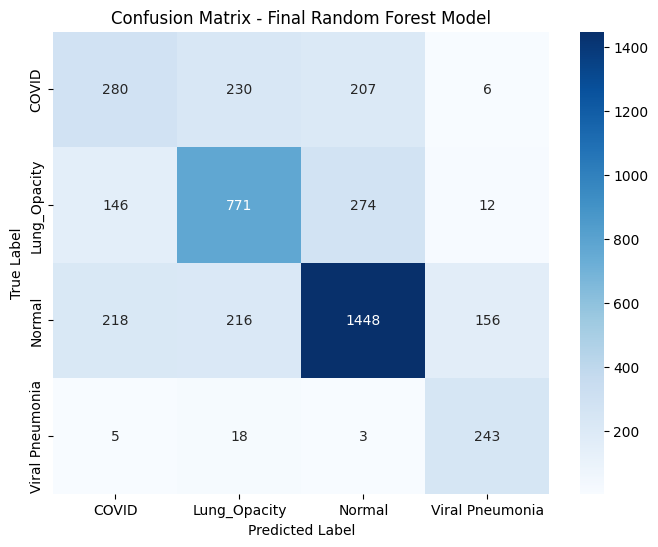

In [13]:
# Cell 12 - Evaluate the final Random Forest model performance


# Compute overall accuracy on the test dataset
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Display detailed classification metrics
print("\nClassification Report:")

# Shows precision, recall, F1-score and support for each class
print(classification_report(y_test, y_pred))

# Prepare class labels for the confusion matrix
class_names = sorted(np.unique(y_test))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,           # Show values inside cells
    fmt="d",              # Integer format
    cmap="Blues",         # Color palette
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Final Random Forest Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## **Evaluation and Next Steps**

The final Random Forest model achieved an overall test accuracy of approximately **0.65**. However, the performance across classes is uneven.

In particular, the **recall for the COVID class is relatively low (0.39)**. This means that a significant number of COVID cases are not correctly detected by the model. In contrast, other classes such as **Normal** and **Viral Pneumonia** show higher recall values.

These results suggest that using **raw pixel values as input features may not provide sufficiently informative representations** for detecting COVID patterns with classical machine learning models such as Random Forest.

To improve the feature representation, the next step of the project is to apply **Histogram of Oriented Gradients (HOG)** feature extraction. HOG captures edge structures and local gradient patterns in images, which can provide more meaningful information about lung structures and potential abnormalities.

After extracting HOG features from the images, the Random Forest model will be trained again using these new features. The results will then be compared with the baseline model trained on raw pixel values.

In [14]:
# Cell 13 — Extract HOG features from the preprocessed images

# Reshape flattened images back to their original 64x64 shape
# Each image was previously flattened into a vector of length 4096
X_images = X.reshape(-1, 64, 64)


# Convert images to float format (recommended for gradient computation)
X_images = X_images.astype("float32")


# Create a list to store HOG feature vectors
hog_features = []


# Loop through each image and compute its HOG descriptor
for img in X_images:

    hog_vector = hog(
        img,
        orientations=9,          # Number of gradient orientation bins
        pixels_per_cell=(8, 8),  # Size of each cell in pixels
        cells_per_block=(2, 2),  # Number of cells in each block
        block_norm="L2-Hys",     # Block normalization method
        feature_vector=True      # Return the descriptor as a 1D feature vector
    )

    # Store the HOG feature vector
    hog_features.append(hog_vector)


# Convert the list of feature vectors into a NumPy feature matrix
X_hog = np.array(hog_features)


# Print the final feature matrix shape
print("Shape of HOG feature matrix:", X_hog.shape)

Shape of HOG feature matrix: (21165, 1764)


In [19]:
# Cell 14 — Train-test split for HOG features

# Split HOG features into training and test sets
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    X_hog,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_hog shape:", X_train_hog.shape)
print("X_test_hog shape:", X_test_hog.shape)
print("y_train_hog shape:", y_train_hog.shape)
print("y_test_hog shape:", y_test_hog.shape)

X_train_hog shape: (16932, 1764)
X_test_hog shape: (4233, 1764)
y_train_hog shape: (16932,)
y_test_hog shape: (4233,)


In [17]:
# Cell 15 - Hyperparameter tuning for Random Forest on HOG features

rf_hog = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",      # fixed
    class_weight="balanced"   # fixed
)

param_grid_hog = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [1, 3, 5]
}

grid_search_hog = GridSearchCV(
    estimator=rf_hog,
    param_grid=param_grid_hog,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search_hog.fit(X_train_hog, y_train_hog)

best_rf_model_hog = grid_search_hog.best_estimator_

print("\nBest hyperparameters found for HOG:")
print(grid_search_hog.best_params_)

print("\nBest mean cross-validation score (F1 macro) for HOG:")
print(grid_search_hog.best_score_)

print("\nBest trained Random Forest model on HOG:")
print(best_rf_model_hog)

best_index_hog = grid_search_hog.best_index_
train_score_hog = grid_search_hog.cv_results_["mean_train_score"][best_index_hog]

print("\nMean training score of the best HOG model:")
print(train_score_hog)

cv_results_hog_df = pd.DataFrame(grid_search_hog.cv_results_)

print("\nGrid Search results (summary):")

print(cv_results_hog_df[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "rank_test_score"
]])

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best hyperparameters found for HOG:
{'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 300}

Best mean cross-validation score (F1 macro) for HOG:
0.6789586759721297

Best trained Random Forest model on HOG:
RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, n_estimators=300, n_jobs=-1,
                       random_state=42)

Mean training score of the best HOG model:
0.8909936716358378

Grid Search results (summary):
    param_n_estimators  param_max_depth  param_min_samples_leaf  \
0                  100                4                       1   
1                  200                4                       1   
2                  300                4                       1   
3                  100                4                       3   
4                  200                4                       3   
5                  300                4              

### **Model selection analysis (GridSearchCV results on HOG features)**

GridSearchCV evaluated 36 hyperparameter combinations using 5-fold cross-validation on the HOG feature representation, resulting in a total of 180 model fits.

The best hyperparameters identified automatically by GridSearchCV were:

- n_estimators = 300  
- max_depth = 10  
- min_samples_leaf = 3  
- max_features = "sqrt"  
- class_weight = "balanced"

This configuration achieved the highest mean cross-validation F1-macro score:

- F1_macro (validation) = 0.6789

However, the corresponding training score is significantly higher:

- Training score = 0.8910

The large gap between the training score and the validation score indicates that the model is overfitting the training data. Although the model performs very well on the training set, its generalization ability on unseen data is limited.

For this reason, the hyperparameters suggested by GridSearchCV were not directly adopted.

Instead, the full set of results stored in `cv_results_` was carefully analyzed. By comparing `mean_train_score` and `mean_test_score`, a more balanced model configuration was identified, aiming to reduce overfitting while maintaining acceptable predictive performance.

---

### **Final hyperparameter selection (HOG features)**

Although the top-ranked model (with `max_depth = 10`) achieved the highest validation score, it also exhibited a large gap between training and validation scores, suggesting significant overfitting.

To improve generalization, a simpler and more regularized configuration was selected manually from the Grid Search results.

The selected hyperparameters are:

- n_estimators = 300  
- max_depth = 6  
- min_samples_leaf = 5  
- max_features = "sqrt"  
- class_weight = "balanced"

This configuration was chosen because it provides a much smaller gap between training and validation scores, indicating better generalization behavior.

While the validation F1-macro score is lower compared to the best-performing model, this reduction is acceptable in exchange for a more stable and less overfitted model.

This choice reflects a deliberate trade-off between predictive performance and robustness, prioritizing generalization over slight improvements in validation score.

In [22]:
# Cell 16 — Train the final selected Random Forest model on HOG features

# Create the final Random Forest model using the manually selected hyperparameters
rf_model_hog = RandomForestClassifier(
    n_estimators=300,          # Number of trees in the forest
    max_depth=6,               # Maximum depth of each decision tree
    min_samples_leaf=5,        # Minimum samples required in a leaf node
    max_features="sqrt",       # Number of features considered when splitting
    class_weight="balanced",   # Adjust weights to handle class imbalance
    random_state=42,           # Ensure reproducibility
    n_jobs=-1                  # Use all CPU cores for training
)

# Train the model using HOG feature representations
rf_model_hog.fit(X_train_hog, y_train_hog)
print("Final Random Forest model training completed.")

# Predict labels for the HOG test set
y_pred_hog = rf_model_hog.predict(X_test_hog)
print("Prediction on the test set completed.")

Final Random Forest model training completed.
Prediction on the test set completed.


Test Accuracy (HOG features): 0.6231986770611859

Classification Report (HOG features):

                 precision    recall  f1-score   support

          COVID       0.48      0.46      0.47       723
   Lung_Opacity       0.58      0.60      0.59      1203
         Normal       0.75      0.65      0.70      2038
Viral Pneumonia       0.48      0.94      0.64       269

       accuracy                           0.62      4233
      macro avg       0.57      0.66      0.60      4233
   weighted avg       0.64      0.62      0.62      4233



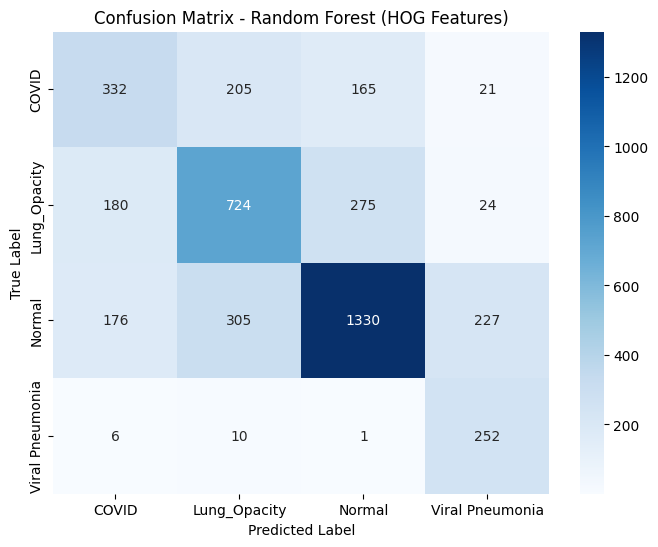

In [23]:
# Cell 17 - Evaluate the Random Forest model performance with HOG features

# Compute overall accuracy on test data
accuracy_hog = accuracy_score(y_test_hog, y_pred_hog)

print("Test Accuracy (HOG features):", accuracy_hog)


# Print detailed classification metrics
print("\nClassification Report (HOG features):\n")
print(classification_report(y_test_hog, y_pred_hog))


# Get class names directly from the data (sorted to match sklearn behavior)
class_names = sorted(np.unique(y_test_hog))


# Compute confusion matrix using the same class order
cm_hog = confusion_matrix(y_test_hog, y_pred_hog, labels=class_names)


# Plot confusion matrix as a colored heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_hog,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Random Forest (HOG Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**HOG** improved the performance compared with raw pixels, but the improvement remains limited. This suggests that feature extraction helps, but Random Forest may not be the most suitable classifier for this medical imaging task.